In [1]:
"""Show the results of the optimization on the VLSE benchmark."""

# Copyright (c) 2025 Alliance for Energy Innovation, LLC

# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.

# This program is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
# GNU General Public License for more details.

# You should have received a copy of the GNU General Public License
# along with this program.  If not, see <http://www.gnu.org/licenses/>.

__authors__ = ["Weslley S. Pereira"]
__contact__ = "weslley.dasilvapereira@nrel.gov"
__maintainer__ = "Weslley S. Pereira"
__email__ = "weslley.dasilvapereira@nrel.gov"
__credits__ = ["Weslley S. Pereira"]
__deprecated__ = False

# VLSE benchmark results

This notebook is used to read results generated by [vlse_bench.py](vlse_bench.py). The results are Pickle files that contain information about the optimization runs. Each file concerns a single problem and a single algorithm, used to solve the problem. Mind that filenames ending with `default` use the default bounds for a problem, and filenames ending with `bounds` use user-defined bounds.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

from vlse_bench import myFuncs

boundflag = "default"

myFuncStr = (
    "branin",
    "hart3",
    "hart6",
    "shekel",
    "ackley",
    "levy",
    "powell",
    "michal",
    "spheref",
    "rastr",
    "mccorm",
    "bukin6",
    "camel6",
    "crossit",
    "drop",
    "egg",
    "griewank",
    "holder",
    "levy13",
)
myAlgorithmStrPickle = ["SRS", "DYCORS", "CPTV", "CPTVl"]
myAlgorithmStr = ["Multistart LMSRS", "DYCORS", "CPTV", "CPTVl"]

nTrials = 0
optres = {}
exectime = {}
maxIter = {}
myNArgs = {}
minVal = {}

In [3]:
# import sys
# import soogo

# # Comment out if using new versions of this repo (>= v1.0)
# sys.modules["blackboxopt"] = soogo

# Initialize algorithm specific dictionaries
for i in range(len(myAlgorithmStr)):
    a = myAlgorithmStr[i]
    pickle_a = myAlgorithmStrPickle[i]
    optres[a] = {}
    exectime[a] = {}
    for rFunc in myFuncStr:
        optres[a][rFunc] = []
        exectime[a][rFunc] = 0.0
        with open(
            "pickle/" + rFunc + "_" + pickle_a + "_" + boundflag + ".pkl", "rb"
        ) as f:
            (
                _,
                _,
                nTrials,
                optres[a][rFunc],
                exectime[a][rFunc],
                _,
            ) = pickle.load(f)

# Initialize the remaining dictionaries with data from one of the algorithms
for rFunc in myFuncStr:
    maxIter[rFunc] = optres["DYCORS"][rFunc][0].nit
    for i in range(nTrials):
        assert maxIter[rFunc] == optres["DYCORS"][rFunc][i].nit
    myNArgs[rFunc] = len(myFuncs[rFunc].domain())
    minVal[rFunc] = myFuncs[rFunc].min()

For each problem, we can plot the average best values an algorithm obtain per function evaluation. We can also compare the minimum values found by the algorithms with the known minimum values for each problem.

Problem branin with 2 arguments
Minimum known value: 0.397887
Minimum observed value: 0.3978873577297488 at [3.14159261 2.27500004] by CPTVl algorithm
Average best value for Multistart LMSRS: 0.39788749816753227
Average best value for DYCORS: 0.39788769586569533
Average best value for CPTV: 0.3978875126744885
Average best value for CPTVl: 0.3978873577297488


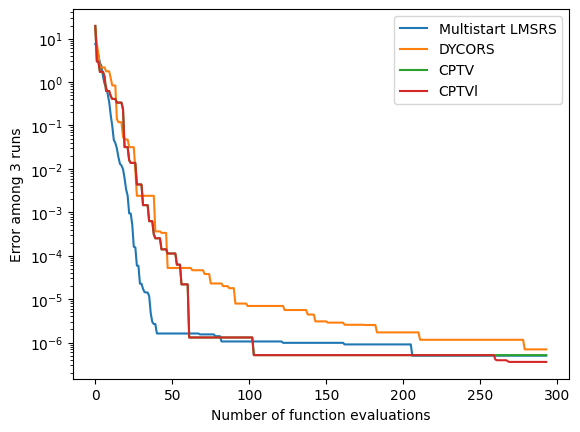

Problem hart3 with 3 arguments
Minimum known value: -3.86278
Minimum observed value: -3.862779785889427 at [0.11459108 0.55564286 0.85254546] by CPTVl algorithm
Average best value for Multistart LMSRS: -3.853864463315567
Average best value for DYCORS: -3.8627791221751706
Average best value for CPTV: -3.862777022273869
Average best value for CPTVl: -3.862779785626532


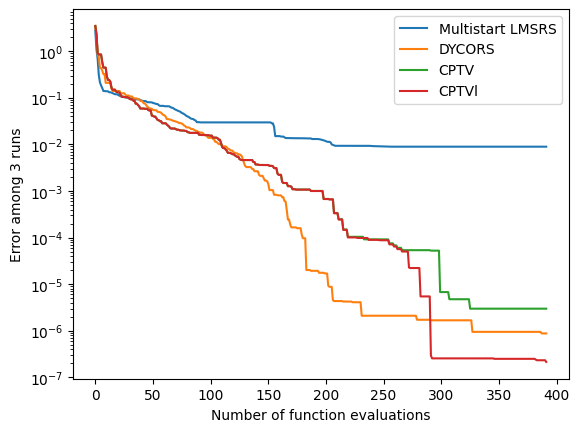

Problem hart6 with 6 arguments
Minimum known value: -3.04245876289
Minimum observed value: -3.0424577351082687 at [0.20169396 0.15001073 0.47687597 0.27532999 0.31165156 0.65728689] by CPTVl algorithm
Average best value for Multistart LMSRS: -3.042447853731394
Average best value for DYCORS: -3.0014891811851445
Average best value for CPTV: -3.0014787088704504
Average best value for CPTVl: -3.00149343948536


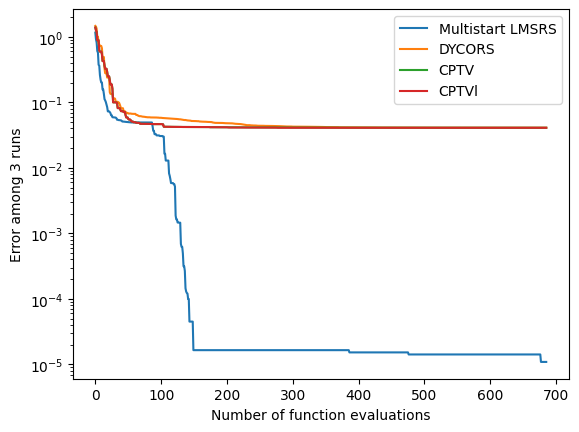

Problem shekel with 4 arguments
Minimum known value: -10.53644315348353
Minimum observed value: -10.536155618534018 at [4.00125203 4.00037824 3.99940443 3.99976176] by DYCORS algorithm
Average best value for Multistart LMSRS: -8.380394911963721
Average best value for DYCORS: -8.380268784721606
Average best value for CPTV: -3.278636024131387
Average best value for CPTVl: -3.278725924406153


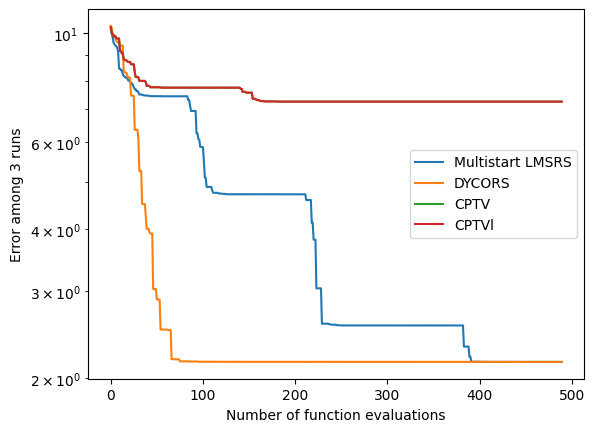

Problem ackley with 15 arguments
Minimum known value: 0.0
Minimum observed value: 3.241851231905457e-14 at [-4.78089790e-15 -8.01268774e-15 -2.20656826e-15 -1.19765309e-14
 -1.52655666e-16 -1.07552856e-15 -1.19244892e-14 -1.14630527e-14
 -7.70217223e-15 -2.81025203e-15 -9.49240686e-15 -4.45130044e-15
 -5.80091530e-15 -7.63972219e-15 -1.68285524e-14] by CPTVl algorithm
Average best value for Multistart LMSRS: 0.4107205772736191
Average best value for DYCORS: 0.4644558071383173
Average best value for CPTV: 0.023626868018802316
Average best value for CPTVl: 3.597122599785507e-14


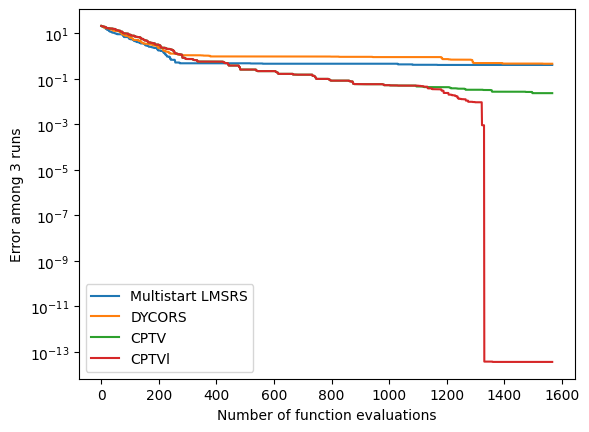

Problem levy with 20 arguments
Minimum known value: 0.0
Minimum observed value: 8.593167919970059e-10 at [0.9999996  0.99999031 0.99999031 0.99999031 0.99999031 0.99999031
 0.99999031 0.99999031 0.99999031 0.99999031 0.99999031 0.99999031
 0.99999031 0.99999031 0.99999031 0.99999031 0.99999031 0.99999031
 0.99999031 0.99999039] by CPTVl algorithm
Average best value for Multistart LMSRS: 3.4346799808377217
Average best value for DYCORS: 2.965555140597697
Average best value for CPTV: 2.5334846000934186
Average best value for CPTVl: 8.593167924732926e-10


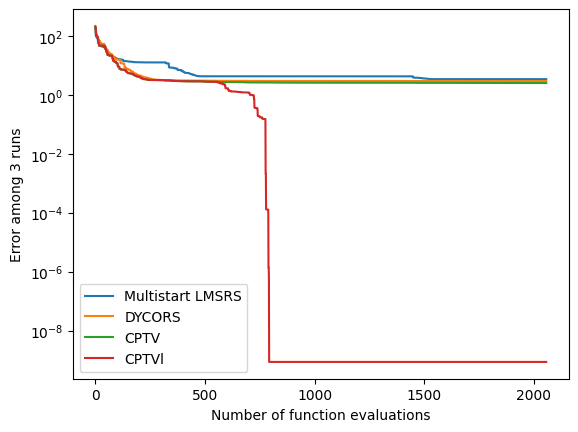

Problem powell with 24 arguments
Minimum known value: 0.0
Minimum observed value: 0.000843197229851176 at [-0.06245169  0.00622975 -0.03241362 -0.03235836 -0.10277679  0.01023707
 -0.05693608 -0.05730777 -0.06036111  0.0060154  -0.03605668 -0.03592749
 -0.03796634  0.00381667  0.03016084  0.02896992  0.06856082 -0.00683792
  0.03500724  0.03515489  0.09624854 -0.0096045   0.05258712  0.05448974] by CPTVl algorithm
Average best value for Multistart LMSRS: 17.798651529308675
Average best value for DYCORS: 0.0916349679670244
Average best value for CPTV: 0.3107156705150642
Average best value for CPTVl: 0.042901233656612504


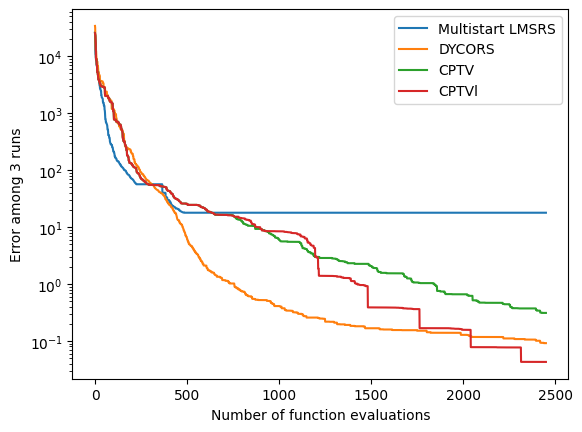

Problem michal with 20 arguments
Minimum known value: -19.6370136
Minimum observed value: -15.160953192238702 at [2.14426014 1.59270724 2.4418334  1.92233788 1.98489059 1.58117956
 0.83315068 1.3584432  0.70474091 0.70810942 2.00613509 1.43296667
 2.04629506 0.58623349 0.99797094 1.24665774 0.92803045 1.57098096
 1.53252617 1.11249844] by CPTV algorithm
Average best value for Multistart LMSRS: -13.473964432393347
Average best value for DYCORS: -12.077453006830481
Average best value for CPTV: -14.372485572237572
Average best value for CPTVl: -14.372485572237572


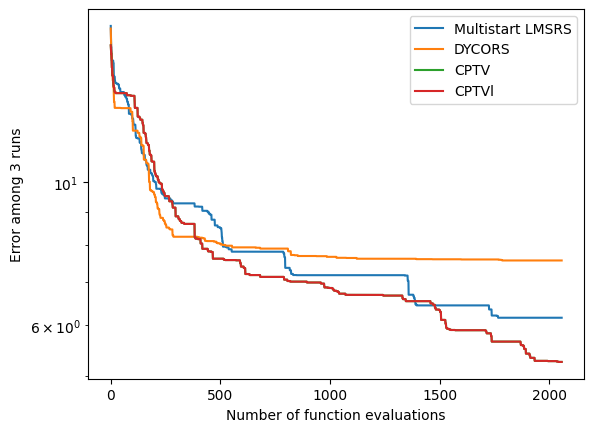

Problem spheref with 27 arguments
Minimum known value: 0.0
Minimum observed value: 1.235890310172056e-31 at [-4.16333634e-17  1.28369537e-16  8.32667268e-17  4.85722573e-17
  8.67361738e-17  3.46944695e-17  5.55111512e-17  1.51788304e-16
  4.85722573e-17  1.38777878e-17  6.93889390e-18 -1.73472348e-17
  5.20417043e-17 -1.09287579e-16 -4.51028104e-17 -1.38777878e-17
  5.55111512e-17  1.07552856e-16 -1.04083409e-17  5.55111512e-17
  9.02056208e-17  2.08166817e-17  6.93889390e-17 -3.46944695e-18
  1.73472348e-17 -5.46437895e-17 -8.32667268e-17] by CPTVl algorithm
Average best value for Multistart LMSRS: 0.0069311294573170465
Average best value for DYCORS: 0.004974629112719661
Average best value for CPTV: 0.0009409321965900807
Average best value for CPTVl: 1.6296158736767767e-31


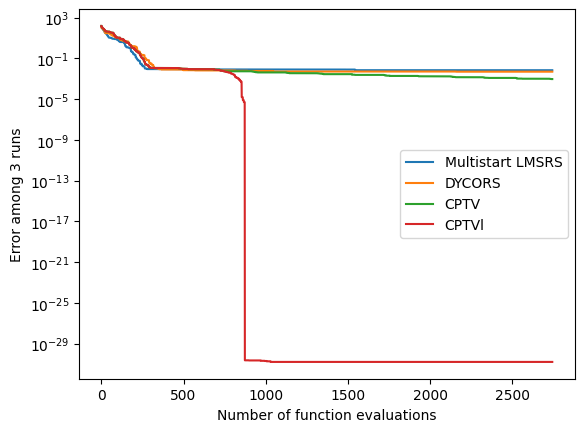

Problem rastr with 30 arguments
Minimum known value: 0.0
Minimum observed value: 0.0 at [8.43596026e-15 8.21565038e-15 5.72458747e-15 8.43769499e-15
 8.43769499e-15 1.15463195e-14 1.43218770e-14 1.15463195e-14
 1.37667655e-14 8.43769499e-15 1.42108547e-14 8.21565038e-15
 1.15463195e-14 1.42663659e-14 1.11022302e-14 1.11022302e-14
 5.77315973e-15 1.15463195e-14 1.15463195e-14 8.43769499e-15
 8.43769499e-15 1.15463195e-14 1.15463195e-14 8.21565038e-15
 1.42108547e-14 5.55111512e-15 5.32907052e-15 5.32907052e-15
 5.32907052e-15 5.66213743e-15] by CPTVl algorithm
Average best value for Multistart LMSRS: 82.26607077514079
Average best value for DYCORS: 130.04117542483996
Average best value for CPTV: 102.01857029648488
Average best value for CPTVl: 0.0


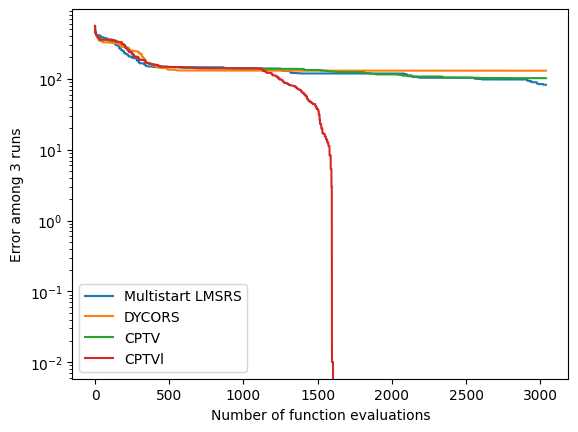

Problem mccorm with 2 arguments
Minimum known value: -1.9133
Minimum observed value: -1.9132229549797546 at [-0.54719699 -1.54719654] by CPTVl algorithm
Average best value for Multistart LMSRS: -1.913222932140517
Average best value for DYCORS: -1.9132229343299187
Average best value for CPTV: -1.9132224296396376
Average best value for CPTVl: -1.9132229549646163


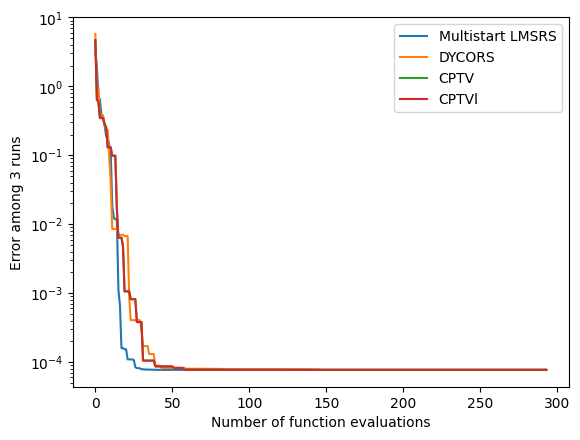

Problem bukin6 with 2 arguments
Minimum known value: 0.0
Minimum observed value: 0.002034777051903216 at [-9.80114165  0.96062378] by CPTVl algorithm
Average best value for Multistart LMSRS: 0.37777679134756625
Average best value for DYCORS: 0.2845095294118045
Average best value for CPTV: 0.40065640628290383
Average best value for CPTVl: 0.09224119503289728


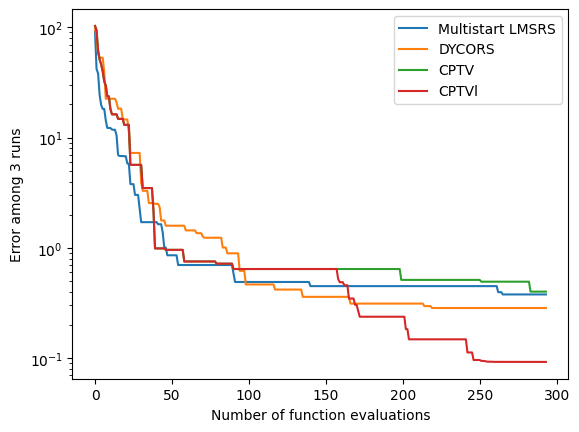

Problem camel6 with 2 arguments
Minimum known value: -1.0316284505642321
Minimum observed value: -1.0316284505642321 at [-0.0898216   0.71266783] by Multistart LMSRS algorithm
Average best value for Multistart LMSRS: -1.0316284208707651
Average best value for DYCORS: -1.0316283708596456
Average best value for CPTV: -1.0316283844533138
Average best value for CPTVl: -1.0316283844533138


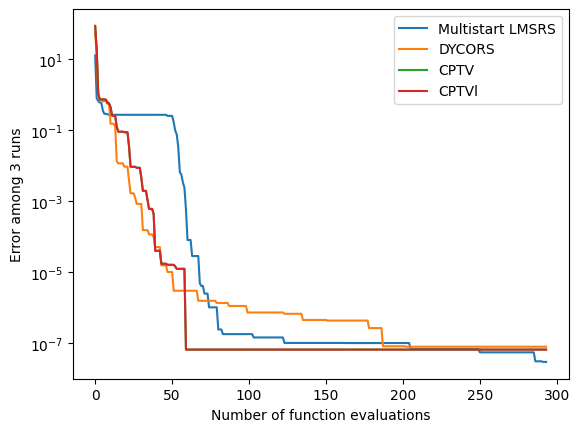

Problem crossit with 2 arguments
Minimum known value: -2.062611870810099
Minimum observed value: -2.062611870810099 at [1.34940047 1.34939777] by CPTVl algorithm
Average best value for Multistart LMSRS: -2.062611800393826
Average best value for DYCORS: -2.0626118227505903
Average best value for CPTV: -2.062611786771679
Average best value for CPTVl: -2.0626118708063124


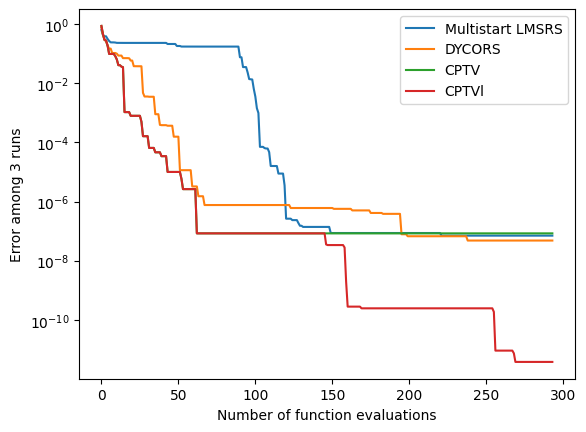

Problem drop with 2 arguments
Minimum known value: -1.0
Minimum observed value: -0.9362452960440177 at [0.51827083 0.04458405] by CPTV algorithm
Average best value for Multistart LMSRS: -0.8860805652386503
Average best value for DYCORS: -0.41479361809579784
Average best value for CPTV: -0.9362449152460478
Average best value for CPTVl: -0.9362449152460478


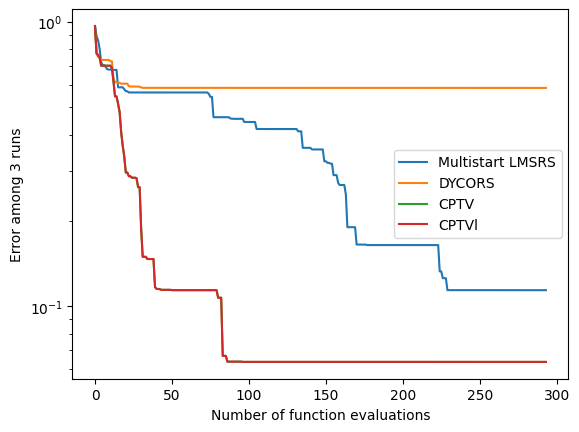

Problem egg with 2 arguments
Minimum known value: -959.6407
Minimum observed value: -935.3367574511315 at [439.56191502 454.04275689] by CPTV algorithm
Average best value for Multistart LMSRS: -809.4243852107056
Average best value for DYCORS: -757.4049572031312
Average best value for CPTV: -897.2749968078859
Average best value for CPTVl: -919.8592347980175


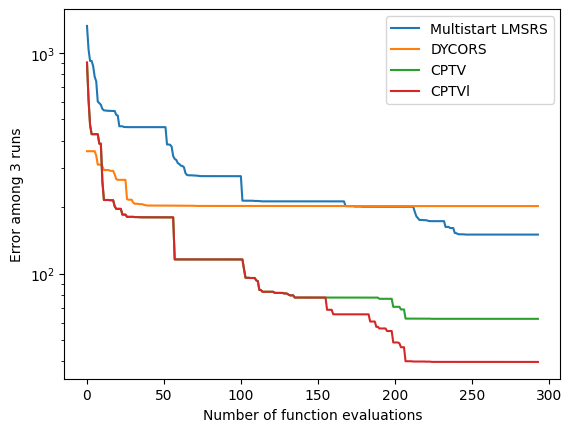

Problem griewank with 2 arguments
Minimum known value: 0.0
Minimum observed value: 0.0 at [-1.97716843e-13 -2.09610107e-13] by CPTVl algorithm
Average best value for Multistart LMSRS: 0.03557108707393308
Average best value for DYCORS: 0.06225637006010706
Average best value for CPTV: 0.01094082045317124
Average best value for CPTVl: 0.0


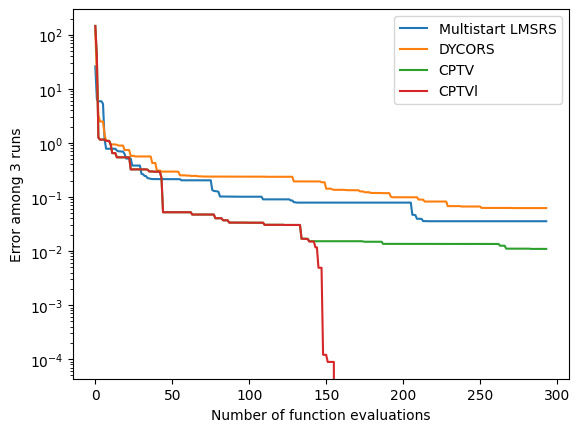

Problem holder with 2 arguments
Minimum known value: -19.20850256786981
Minimum observed value: -19.20850256786981 at [-8.05502475 -9.66458972] by CPTV algorithm
Average best value for Multistart LMSRS: -19.208497404374118
Average best value for DYCORS: -19.208497780047196
Average best value for CPTV: -19.20849824578608
Average best value for CPTVl: -19.208500726584223


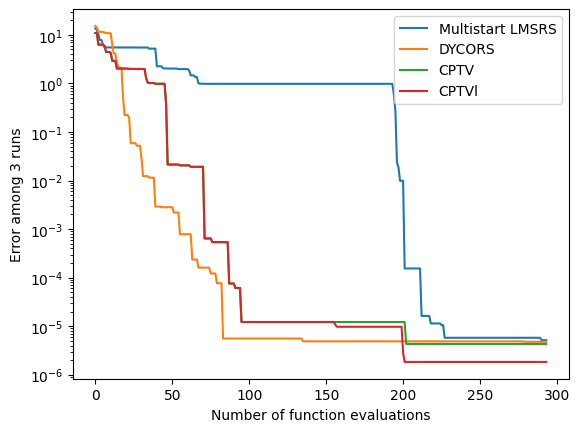

Problem levy13 with 2 arguments
Minimum known value: 0.0
Minimum observed value: 4.508831811037781e-12 at [1.         1.00000212] by CPTVl algorithm
Average best value for Multistart LMSRS: 0.000527882448191402
Average best value for DYCORS: 0.03664676170681251
Average best value for CPTV: 1.8337087577619777e-06
Average best value for CPTVl: 4.508831862901653e-12


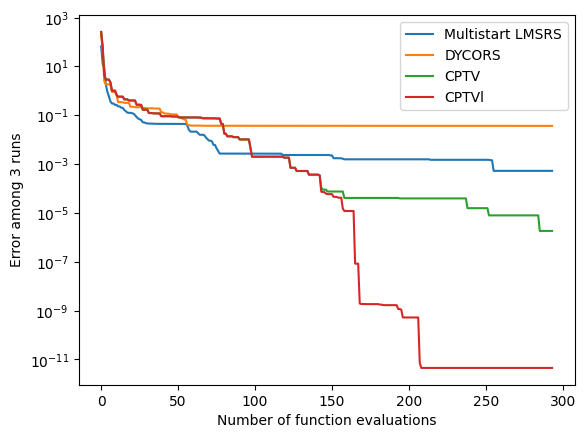

In [4]:
avgBestVals = {}
minBestPts = {}
minBestVals = {rFunc: np.inf for rFunc in myFuncStr}
bestAlgorithm = {}

for a in myAlgorithmStr:
    avgBestVals[a] = {}
    for rFunc in myFuncStr:
        # Compute average best values for each problem solved by an algorithm
        aux = np.array(
            [
                np.minimum.accumulate(optres[a][rFunc][i].fsample).tolist()
                for i in range(nTrials)
            ]
        )
        avgBestVals[a][rFunc] = np.mean(aux, axis=0)

        # Compute the best values overall all algorithms for a given problem
        idx = np.argmin(aux)
        row_idx, col_idx = np.unravel_index(idx, aux.shape)
        if aux[row_idx, col_idx] < minBestVals[rFunc]:
            minBestPts[rFunc] = optres[a][rFunc][row_idx].sample[col_idx]
            minBestVals[rFunc] = aux[row_idx, col_idx]
            bestAlgorithm[rFunc] = a

# For each problem, compares how good an algorithm can estimate the global
# minimum
for rFunc in myFuncStr:
    print(f"Problem {rFunc} with {myNArgs[rFunc]} arguments")
    print(f"Minimum known value: {minVal[rFunc]}")
    print(
        f"Minimum observed value: {minBestVals[rFunc]} at {minBestPts[rFunc]} by {bestAlgorithm[rFunc]} algorithm"
    )
    for a in myAlgorithmStr:
        print(
            "Average best value for "
            + a
            + ": "
            + str(avgBestVals[a][rFunc][-1])
        )
        plt.plot(avgBestVals[a][rFunc] - minVal[rFunc], label=a)
    plt.xlabel("Number of function evaluations")
    plt.ylabel(f"Error among {nTrials} runs")
    plt.yscale("log")
    plt.legend()
    plt.show()

We can summarize those results using two metrics, both based on the number of function evaluations $\ell_{\gamma,a}$ that an algorithm $a$ needs to solve a problem $\gamma$. We say a problem is solved by the algorithm if the best value the algorithm encounters is at most 1% above from the known solution. If the known solution is 0, then we use the absolute tolerance of 1e-6 for the best value.

For the first metric, we define the performance ratio, as $\ell_{\gamma,a} / \min_a \ell_{\gamma,a}$, which goes from 1 to infinity. The $\rho_a(\alpha)$ metric of an algorithm $a$ is the number of problems that the algorithm can solve with performance ratio of at most $\alpha$, divided by the total number of problems.

The second metric is $\delta_a(\kappa)$. It measures how many problems an algorithm $a$ can solve with $\kappa (n+1)$ iterations, divided by the total number of problems. The value $n$ is the number of dimensions in the domain space, and $\kappa$ is a metric known as the number of simplex gradients in a $n$-dimensional space.

In [14]:
rtau = 1e-3  # Relative tolerance to consider the algorithm has converged
atau = 1e-6  # Absolute tolerance to consider the algorithm has converged, only used when the known minimum is zero.

# Number of function evaluations for an algorithm to converge for a given
# problem.
lpa = {}
for a in myAlgorithmStr:
    lpa[a] = {}
    for rFunc in myFuncStr:
        count = 0
        if minVal[rFunc] == 0:
            while count < len(avgBestVals[a][rFunc]):
                if avgBestVals[a][rFunc][count] - minVal[rFunc] <= atau:
                    break
                else:
                    count += 1
        else:
            while count < len(avgBestVals[a][rFunc]):
                if avgBestVals[a][rFunc][count] - minVal[rFunc] <= rtau * abs(
                    minVal[rFunc]
                ):
                    break
                else:
                    count += 1

        lpa[a][rFunc] = count + 1


# minimum number of function evaluations needed for every problem
minlpa = {}
for rFunc in myFuncStr:
    minlpa[rFunc] = np.min([lpa[a][rFunc] for a in myAlgorithmStr])

# performance ratio, lpa / min(lpa). Lower is better
rpa = {}
for a in myAlgorithmStr:
    rpa[a] = {}
    for rFunc in myFuncStr:
        if lpa[a][rFunc] <= maxIter[rFunc]:
            rpa[a][rFunc] = lpa[a][rFunc] / minlpa[rFunc]
        else:
            rpa[a][rFunc] = np.inf

# Rho measure: Average performance ratio of an algorithm
nAlpha = 100
alpha = np.linspace(1.0, 4.0, nAlpha)
rho = {}
for a in myAlgorithmStr:
    rho[a] = np.zeros(nAlpha)
    for k in range(len(alpha)):
        count = 0
        for rFunc in myFuncStr:
            if rpa[a][rFunc] <= alpha[k]:
                count += 1
        rho[a][k] = count / len(myFuncStr)

# delta measure: Average number of function evaluations an algorithm needed.
# Use number of simplex gradients to compare problems with domains with
# different number of dimensions.
maxKappa = 98
delta = {}
for a in myAlgorithmStr:
    delta[a] = np.zeros(maxKappa + 1)
    for k in range(1, maxKappa + 1):
        count = 0
        for rFunc in myFuncStr:
            if lpa[a][rFunc] / (myNArgs[rFunc] + 1) <= k:
                count += 1
        delta[a][k] = count / len(myFuncStr)

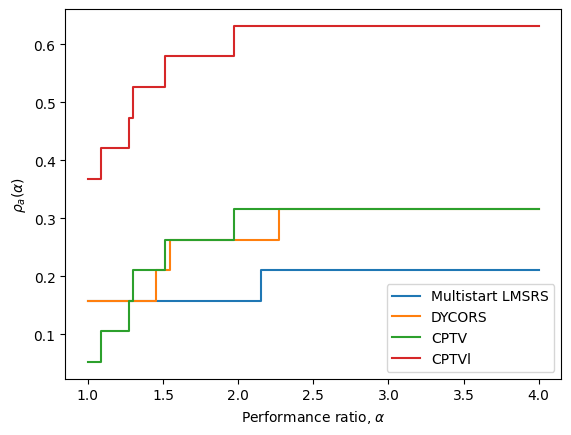

In [15]:
iter = 0
deltaStep = 0.0
for a in myAlgorithmStr:
    plt.step(alpha, rho[a] + deltaStep * iter, where="post", label=a)
    iter += 1
plt.xlabel(r"Performance ratio, $\alpha$")
plt.ylabel(r"$\rho_a(\alpha)$")
plt.legend()
plt.show()

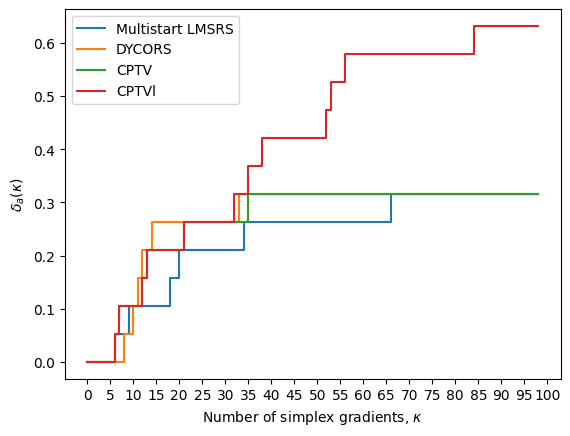

In [16]:
iter = 0
deltaStep = 0.0
for a in myAlgorithmStr:
    plt.step(
        np.arange(0, maxKappa + 1),
        delta[a] + deltaStep * iter,
        where="post",
        label=a,
    )
    iter += 1
plt.xlabel(r"Number of simplex gradients, $\kappa$")
plt.xticks(range(0, 101, 5))
plt.ylabel(r"$\delta_a(\kappa)$")
plt.legend()
plt.show()